# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 02: STRUCTURED MODEL USING FEATURES.CSV
# ============================================================

In [19]:


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:

# ============================================================
# 2. LOAD DATA (same as previous notebook)
# ============================================================

tracks = pd.read_csv(
    "../data/raw/metadata/tracks.csv",
    header=[0, 1],
    index_col=0
)

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)


In [21]:
# ============================================================
# 3. FILTER TO SMALL DATASET
# ============================================================

tracks_small = tracks[tracks[("set", "subset")] == "small"]

labels = tracks_small[("track", "genre_top")]
splits = tracks_small[("set", "split")]

features_small = features.loc[tracks_small.index]

In [22]:
# ============================================================
# 4. CLEAN DATA
# ============================================================

valid = labels.notna()

X = features_small[valid]
y = labels[valid]
split = splits[valid]


In [23]:
# ============================================================
# 5. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

X_train = X[split == "training"]
y_train = y[split == "training"]

X_val = X[split == "validation"]
y_val = y[split == "validation"]

X_test = X[split == "test"]
y_test = y[split == "test"]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (6400, 518)
Validation: (800, 518)
Test: (800, 518)


In [24]:
# ============================================================
# 6. SCALE DATA (IMPORTANT FOR ML MODELS)
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [25]:
# ============================================================
# 7. MODEL 1: LOGISTIC REGRESSION
# BASELINE MODELS
# These models use default parameters
# ============================================================

print("\n===== LOGISTIC REGRESSION =====")

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

val_pred_lr = lr.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_lr))
print(classification_report(y_val, val_pred_lr))


===== LOGISTIC REGRESSION =====
Validation Accuracy: 0.50375
               precision    recall  f1-score   support

   Electronic       0.47      0.61      0.53       100
 Experimental       0.35      0.41      0.38       100
         Folk       0.66      0.76      0.71       100
      Hip-Hop       0.55      0.52      0.53       100
 Instrumental       0.37      0.26      0.30       100
International       0.62      0.66      0.64       100
          Pop       0.26      0.18      0.21       100
         Rock       0.65      0.63      0.64       100

     accuracy                           0.50       800
    macro avg       0.49      0.50      0.49       800
 weighted avg       0.49      0.50      0.49       800



In [26]:
# ============================================================
# 8. MODEL 2: RANDOM FOREST
# BASELINE MODELS
# These models use default parameters
# ============================================================

print("\n===== RANDOM FOREST =====")

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

val_pred_rf = rf.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_rf))
print(classification_report(y_val, val_pred_rf))


===== RANDOM FOREST =====
Validation Accuracy: 0.535
               precision    recall  f1-score   support

   Electronic       0.51      0.64      0.57       100
 Experimental       0.52      0.54      0.53       100
         Folk       0.57      0.75      0.65       100
      Hip-Hop       0.63      0.62      0.62       100
 Instrumental       0.42      0.37      0.39       100
International       0.65      0.51      0.57       100
          Pop       0.15      0.08      0.10       100
         Rock       0.64      0.77      0.70       100

     accuracy                           0.54       800
    macro avg       0.51      0.54      0.52       800
 weighted avg       0.51      0.54      0.52       800



In [27]:
# ============================================================
# 9. MODEL 3: SVM
# BASELINE MODELS
# These models use default parameters
# ============================================================

print("\n===== SVM =====")

svm = SVC()

svm.fit(X_train_scaled, y_train)

val_pred_svm = svm.predict(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_svm))
print(classification_report(y_val, val_pred_svm))


===== SVM =====
Validation Accuracy: 0.5575
               precision    recall  f1-score   support

   Electronic       0.55      0.68      0.61       100
 Experimental       0.42      0.64      0.51       100
         Folk       0.71      0.80      0.75       100
      Hip-Hop       0.62      0.60      0.61       100
 Instrumental       0.37      0.24      0.29       100
International       0.77      0.64      0.70       100
          Pop       0.24      0.15      0.18       100
         Rock       0.68      0.71      0.70       100

     accuracy                           0.56       800
    macro avg       0.54      0.56      0.54       800
 weighted avg       0.54      0.56      0.54       800



In [28]:
# ============================================================
# 10. FINAL TEST EVALUATION (BEST MODEL)
# ============================================================

print("\n===== FINAL TEST (Random Forest) =====")

test_pred_rf = rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, test_pred_rf))
print(classification_report(y_test, test_pred_rf))



===== FINAL TEST (Random Forest) =====
Test Accuracy: 0.46375
               precision    recall  f1-score   support

   Electronic       0.50      0.56      0.53       100
 Experimental       0.31      0.31      0.31       100
         Folk       0.26      0.30      0.28       100
      Hip-Hop       0.63      0.66      0.65       100
 Instrumental       0.43      0.40      0.41       100
International       0.52      0.48      0.50       100
          Pop       0.39      0.33      0.36       100
         Rock       0.68      0.67      0.67       100

     accuracy                           0.46       800
    macro avg       0.47      0.46      0.46       800
 weighted avg       0.47      0.46      0.46       800



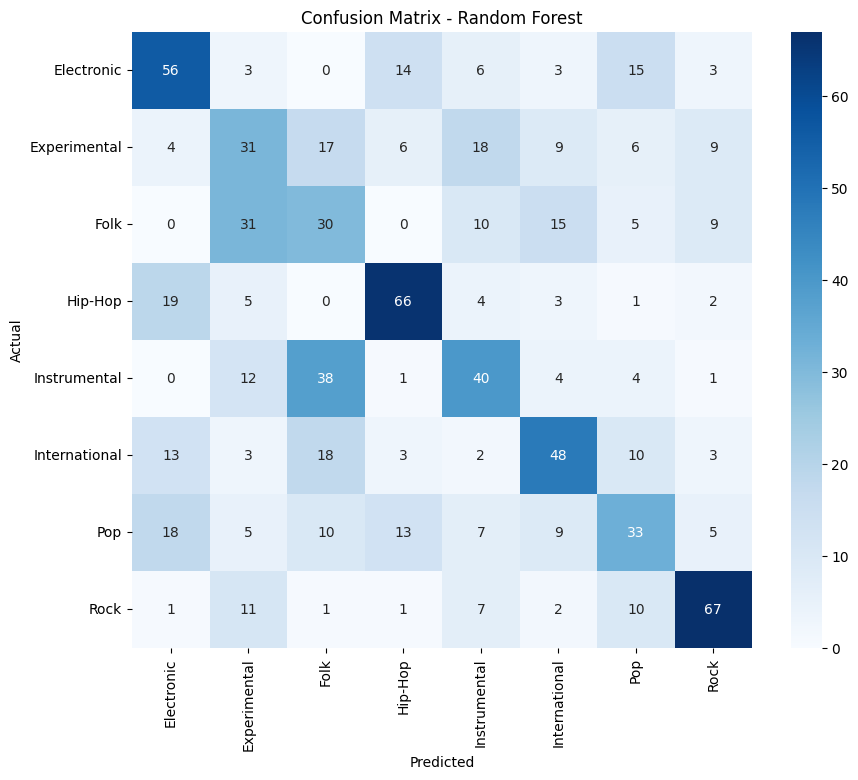

In [29]:
# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf.classes_,
            yticklabels=rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# ============================================================
# 12. IMPROVED / TUNED MODELS
# ============================================================
# The previous models were baseline models.
# This section improves selected models by adjusting parameters.
# We keep the baseline results so we can compare before vs after.

In [12]:
# ============================================================
# 12.1 IMPROVED RANDOM FOREST
# ============================================================
# Changes made:
# - n_estimators increased from 100 to 300
# - max_depth added to control how deep each tree can grow
# - min_samples_split added to reduce overfitting

print("\n===== IMPROVED RANDOM FOREST =====")

rf_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    random_state=42
)

# Train improved Random Forest
rf_improved.fit(X_train, y_train)

# Validate improved Random Forest
val_pred_rf_improved = rf_improved.predict(X_val)

print("Improved Random Forest Validation Accuracy:",
      accuracy_score(y_val, val_pred_rf_improved))

print(classification_report(y_val, val_pred_rf_improved))



===== IMPROVED RANDOM FOREST =====
Improved Random Forest Validation Accuracy: 0.5575
               precision    recall  f1-score   support

   Electronic       0.53      0.60      0.56       100
 Experimental       0.57      0.57      0.57       100
         Folk       0.63      0.80      0.71       100
      Hip-Hop       0.64      0.66      0.65       100
 Instrumental       0.45      0.41      0.43       100
International       0.66      0.57      0.61       100
          Pop       0.16      0.10      0.12       100
         Rock       0.65      0.75      0.69       100

     accuracy                           0.56       800
    macro avg       0.54      0.56      0.54       800
 weighted avg       0.54      0.56      0.54       800



In [13]:
# ============================================================
# 12.2 IMPROVED SVM
# ============================================================
# The baseline SVM performed best on validation data.
# This version adjusts C to allow the model to fit the data better.
# We continue using scaled data because SVM is sensitive to feature scale.

print("\n===== IMPROVED SVM =====")

svm_improved = SVC(
    C=10,
    kernel="rbf",
    gamma="scale"
)

# Train improved SVM
svm_improved.fit(X_train_scaled, y_train)

# Validate improved SVM
val_pred_svm_improved = svm_improved.predict(X_val_scaled)

print("Improved SVM Validation Accuracy:",
      accuracy_score(y_val, val_pred_svm_improved))

print(classification_report(y_val, val_pred_svm_improved))


===== IMPROVED SVM =====
Improved SVM Validation Accuracy: 0.54875
               precision    recall  f1-score   support

   Electronic       0.51      0.65      0.57       100
 Experimental       0.38      0.67      0.49       100
         Folk       0.69      0.81      0.74       100
      Hip-Hop       0.66      0.56      0.61       100
 Instrumental       0.37      0.20      0.26       100
International       0.79      0.67      0.72       100
          Pop       0.25      0.17      0.20       100
         Rock       0.75      0.66      0.70       100

     accuracy                           0.55       800
    macro avg       0.55      0.55      0.54       800
 weighted avg       0.55      0.55      0.54       800



In [14]:
# ============================================================
# 13. FINAL TEST EVALUATION USING BEST IMPROVED MODEL
# ============================================================
# Based on validation accuracy, we test the improved SVM.
# The test set should only be used after selecting the model.

print("\n===== FINAL TEST EVALUATION: IMPROVED SVM =====")

test_pred_svm_improved = svm_improved.predict(X_test_scaled)

print("Improved SVM Test Accuracy:",
      accuracy_score(y_test, test_pred_svm_improved))

print(classification_report(y_test, test_pred_svm_improved))


===== FINAL TEST EVALUATION: IMPROVED SVM =====
Improved SVM Test Accuracy: 0.46125
               precision    recall  f1-score   support

   Electronic       0.52      0.63      0.57       100
 Experimental       0.30      0.43      0.35       100
         Folk       0.20      0.18      0.19       100
      Hip-Hop       0.76      0.74      0.75       100
 Instrumental       0.38      0.33      0.35       100
International       0.61      0.51      0.55       100
          Pop       0.38      0.31      0.34       100
         Rock       0.62      0.56      0.59       100

     accuracy                           0.46       800
    macro avg       0.47      0.46      0.46       800
 weighted avg       0.47      0.46      0.46       800



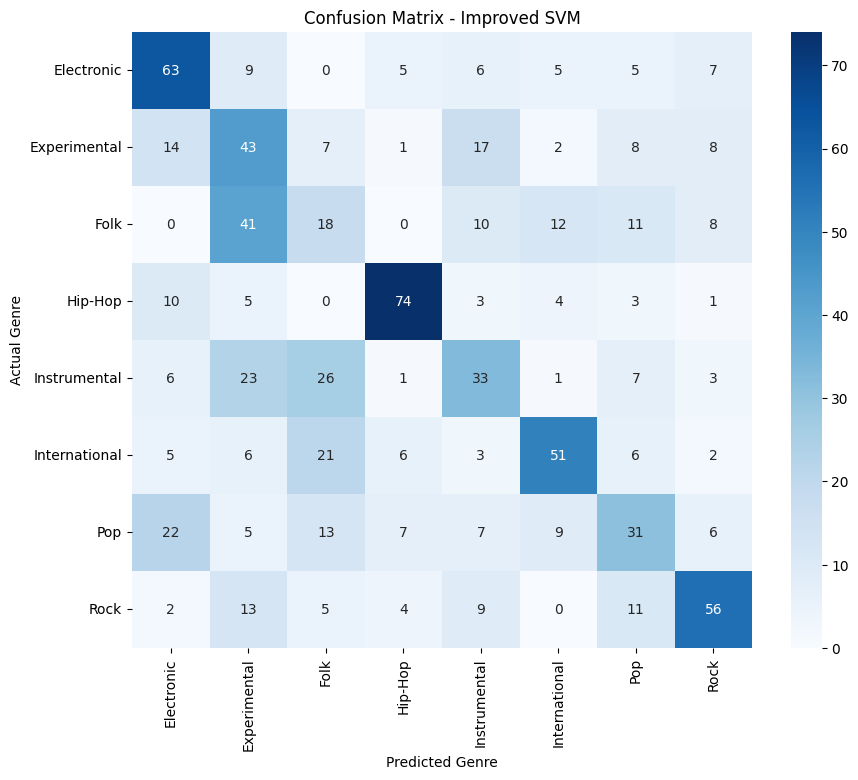

In [15]:
# ============================================================
# 14. CONFUSION MATRIX FOR IMPROVED SVM
# ============================================================
# This shows which genres the improved model predicts correctly
# and which genres are still being confused.

cm_svm_improved = confusion_matrix(y_test, test_pred_svm_improved)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_svm_improved,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_improved.classes_,
    yticklabels=svm_improved.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Improved SVM")
plt.show()




In [16]:
# ============================================================
# 15. FEATURE IMPORTANCE FROM IMPROVED RANDOM FOREST
# ============================================================
# SVM does not easily provide feature importance.
# Random Forest can show which features were most useful.
# This helps with interpretation in the final report.

feature_importance = pd.Series(
    rf_improved.feature_importances_,
    index=X.columns
)

top_features = feature_importance.sort_values(ascending=False).head(20)

print("\nTop 20 Important Features from Improved Random Forest:")
print(top_features)



Top 20 Important Features from Improved Random Forest:
feature             statistics  number
mfcc                mean        03        0.007275
spectral_rolloff    median      01        0.006929
mfcc                max         04        0.006880
                    median      03        0.006839
spectral_centroid   median      01        0.006594
spectral_contrast   median      04        0.006431
                    mean        04        0.006386
spectral_rolloff    mean        01        0.006252
mfcc                median      01        0.006209
rmse                std         01        0.006112
mfcc                mean        01        0.006093
spectral_contrast   median      02        0.005820
spectral_centroid   mean        01        0.005766
spectral_contrast   mean        02        0.005616
                                03        0.005545
spectral_bandwidth  median      01        0.005402
spectral_contrast   mean        07        0.005365
mfcc                max         01    

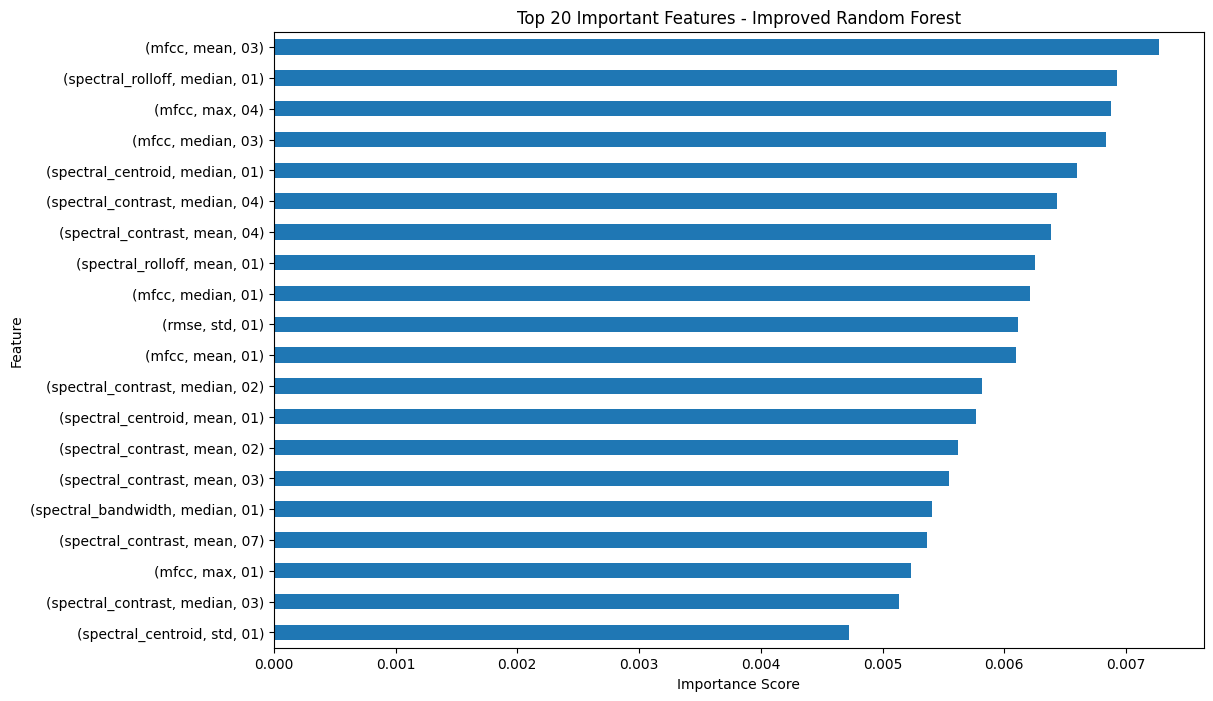

In [17]:
# ============================================================
# 16. PLOT TOP 20 FEATURE IMPORTANCES
# ============================================================
# This visual can be used in the project report.

plt.figure(figsize=(12, 8))
top_features.sort_values().plot(kind="barh")

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Important Features - Improved Random Forest")
plt.show()


In [18]:
# ============================================================
# 17. MODEL COMPARISON SUMMARY
# ============================================================
# This table summarizes baseline and improved model performance.

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression Baseline",
        "Random Forest Baseline",
        "SVM Baseline",
        "Improved Random Forest",
        "Improved SVM"
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, val_pred_lr),
        accuracy_score(y_val, val_pred_rf),
        accuracy_score(y_val, val_pred_svm),
        accuracy_score(y_val, val_pred_rf_improved),
        accuracy_score(y_val, val_pred_svm_improved)
    ]
})

print("\nModel Comparison Summary:")
display(model_results)


Model Comparison Summary:


,Model,Validation Accuracy
0,Logistic Regression Baseline,0.50375
1,Random Forest Baseline,0.53500
2,SVM Baseline,0.55750
3,Improved Random Forest,0.55750
4,Improved SVM,0.54875
